In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [ ]:
data = fetch_california_housing()

X = data.data
y = data.target

print("Number of Samples:", X.shape[0])
print("Number of Features:", X.shape[1])
print("Sample Records:\n", X[:5])

Number of Samples: 20640
Number of Features: 8
Sample Records:
 [[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 7.25740000e+00  5.20000000e+01  8.28813559e+00  1.07344633e+00
   4.96000000e+02  2.80225989e+00  3.78500000e+01 -1.22240000e+02]
 [ 5.64310000e+00  5.20000000e+01  5.81735160e+00  1.07305936e+00
   5.58000000e+02  2.54794521e+00  3.78500000e+01 -1.22250000e+02]
 [ 3.84620000e+00  5.20000000e+01  6.28185328e+00  1.08108108e+00
   5.65000000e+02  2.18146718e+00  3.78500000e+01 -1.22250000e+02]]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def compute_cost(X, y, w):
    m = len(y)
    predictions = X.dot(w)
    cost = (1/(2*m)) * np.sum((predictions - y)**2)
    return cost

In [ ]:
def batch_gd(X, y, lr=0.01, iterations=100):
    m, n = X.shape
    w = np.zeros(n)
    cost_history = []

    for i in range(iterations):
        predictions = X.dot(w)
        gradient = (1/m) * X.T.dot(predictions - y)
        w -= lr * gradient
        cost_history.append(compute_cost(X, y, w))

    return w, cost_history

w_bgd, cost_bgd = batch_gd(X_train, y_train)

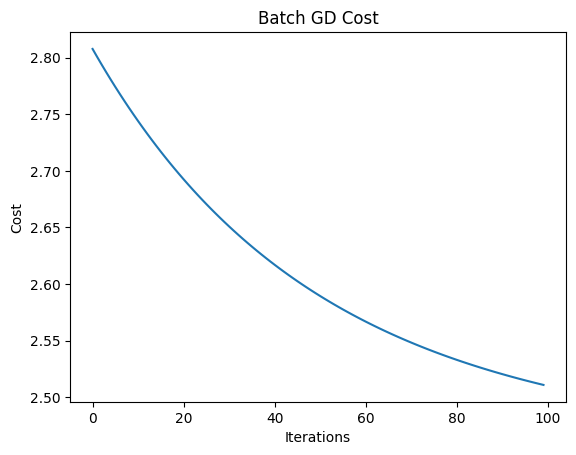

In [ ]:
plt.plot(cost_bgd)
plt.title("Batch GD Cost")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

In [ ]:
def sgd(X, y, lr=0.01, iterations=5):
    m, n = X.shape
    w = np.zeros(n)
    cost_history = []

    for epoch in range(iterations):
        for i in range(m):
            xi = X[i]
            yi = y[i]
            prediction = xi.dot(w)
            gradient = xi * (prediction - yi)
            w -= lr * gradient
            cost_history.append(compute_cost(X, y, w))

    return w, cost_history

w_sgd, cost_sgd = sgd(X_train, y_train)

In [13]:
def mini_batch_gd(X, y, lr=0.01, iterations=50, batch_size=32):
    m, n = X.shape
    w = np.zeros(n)
    cost_history = []

    for _ in range(iterations):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            gradient = X_batch.T.dot(X_batch.dot(w) - y_batch) / len(y_batch)
            w -= lr * gradient

        cost_history.append(compute_cost(X, y, w))

    return w, cost_history

w_mbgd, cost_mbgd = mini_batch_gd(X_train, y_train)

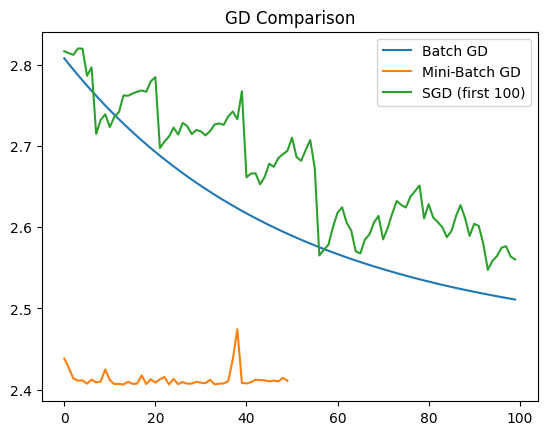

In [14]:
plt.plot(cost_bgd, label="Batch GD")
plt.plot(cost_mbgd, label="Mini-Batch GD")
plt.plot(cost_sgd[:100], label="SGD (first 100)")
plt.legend()
plt.title("GD Comparison")
plt.show()

In [15]:
def rmse(X, y, w):
    pred = X.dot(w)
    return np.sqrt(mean_squared_error(y, pred))

print("BGD RMSE:", rmse(X_test, y_test, w_bgd))
print("SGD RMSE:", rmse(X_test, y_test, w_sgd))
print("Mini-Batch RMSE:", rmse(X_test, y_test, w_mbgd))

BGD RMSE: 2.2361347051242717
SGD RMSE: 2.5615686747584924e+21
Mini-Batch RMSE: 2.2058336000041434


In [16]:
# Conclusion:
# Batch GD is stable but slow, SGD is fast but noisy,
# while Mini-Batch GD provides a balance of speed and smooth convergence.
# Proper normalization and hyperparameter tuning are essential
# for efficient training and better model performance.